### DC demand profiles to understand what we work with

In [5]:
import pandas as pd

df = pd.read_csv("../tests/ukpn-data-centre-demand-profiles.csv")
df.head()

,cleansed_voltage_level,anonymised_data_centre_name,dc_type,local_timestamp,utc_timestamp,hh_utilisation_ratio
0,High Voltage Import,Data Centre #70,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.033600
1,Low Voltage Import,Data Centre #72,Enterprise,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.000000
2,Low Voltage Import,Data Centre #73,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.127279
3,Low Voltage Import,Data Centre #77,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.321519
4,Low Voltage Import,Data Centre #78,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.501500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5390364 entries, 0 to 5390363
Data columns (total 6 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   cleansed_voltage_level       object 
 1   anonymised_data_centre_name  object 
 2   dc_type                      object 
 3   local_timestamp              object 
 4   utc_timestamp                object 
 5   hh_utilisation_ratio         float64
dtypes: float64(1), object(5)
memory usage: 246.8+ MB


In [7]:
df.describe()

,hh_utilisation_ratio
count,5.390364e+06
mean,2.138716e-01
std,2.078744e-01
min,0.000000e+00
25%,4.000000e-02
50%,1.860750e-01
75%,3.292453e-01
max,3.991985e+00


In [8]:
df.groupby('anonymised_data_centre_name')['cleansed_voltage_level'].value_counts(ascending=False)

anonymised_data_centre_name  cleansed_voltage_level   
Data Centre #1               Extra-High Voltage Import    57598
Data Centre #10              High Voltage Import          57550
Data Centre #11              High Voltage Import          57694
Data Centre #12              High Voltage Import          57694
Data Centre #13              High Voltage Import          57694
                                                          ...  
Data Centre #92              Low Voltage Import           57646
Data Centre #93              Low Voltage Import           33312
Data Centre #94              Low Voltage Import           25726
Data Centre #95              Low Voltage Import           57646
Data Centre #96              Extra-High Voltage Import    57454
Name: count, Length: 96, dtype: int64

In [ ]:
VAL = "hh_utilisation_ratio"
DC = "anonymised_data_centre_name"
TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TS = "utc_timestamp"
 
# order voltage levels low->high so plots read sensibly
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]

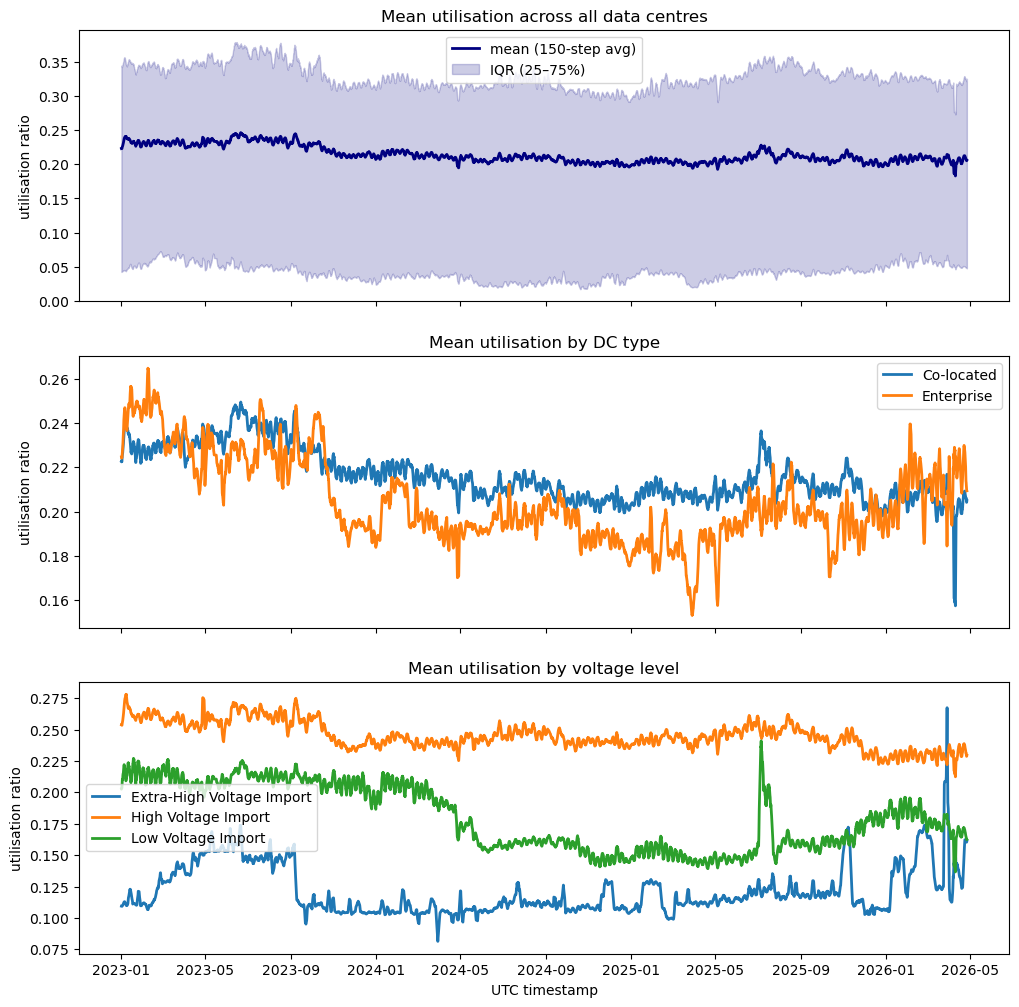

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

df[VAL] = pd.to_numeric(df[VAL], errors="coerce")
df[TS] = pd.to_datetime(df[TS], errors="coerce")

WINDOW = 150   # number of half-hour steps to average over

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

g = df.groupby(TS)[VAL]
mean = g.mean().rolling(WINDOW, center=True, min_periods=1).mean()
lo   = g.quantile(0.25).rolling(WINDOW, center=True, min_periods=1).mean()
hi   = g.quantile(0.75).rolling(WINDOW, center=True, min_periods=1).mean()

axes[0].plot(mean.index, mean.values, color="navy", lw=2, label=f"mean ({WINDOW}-step avg)")
axes[0].fill_between(mean.index, lo, hi, alpha=0.2, color="navy", label="IQR (25–75%)")
axes[0].set_title("Mean utilisation across all data centres")
axes[0].set_ylabel("utilisation ratio")
axes[0].legend()

for label, sub in df.groupby(TYPE):
    m = sub.groupby(TS)[VAL].mean().rolling(WINDOW, center=True, min_periods=1).mean()
    axes[1].plot(m.index, m.values, lw=2, label=label)
axes[1].set_title("Mean utilisation by DC type")
axes[1].set_ylabel("utilisation ratio")
axes[1].legend()

for label, sub in df.groupby(VOLT, observed=True):
    m = sub.groupby(TS)[VAL].mean().rolling(WINDOW, center=True, min_periods=1).mean()
    axes[2].plot(m.index, m.values, lw=2, label=label)
axes[2].set_title("Mean utilisation by voltage level")
axes[2].set_ylabel("utilisation ratio")
axes[2].set_xlabel("UTC timestamp")
axes[2].legend()

plt.show()

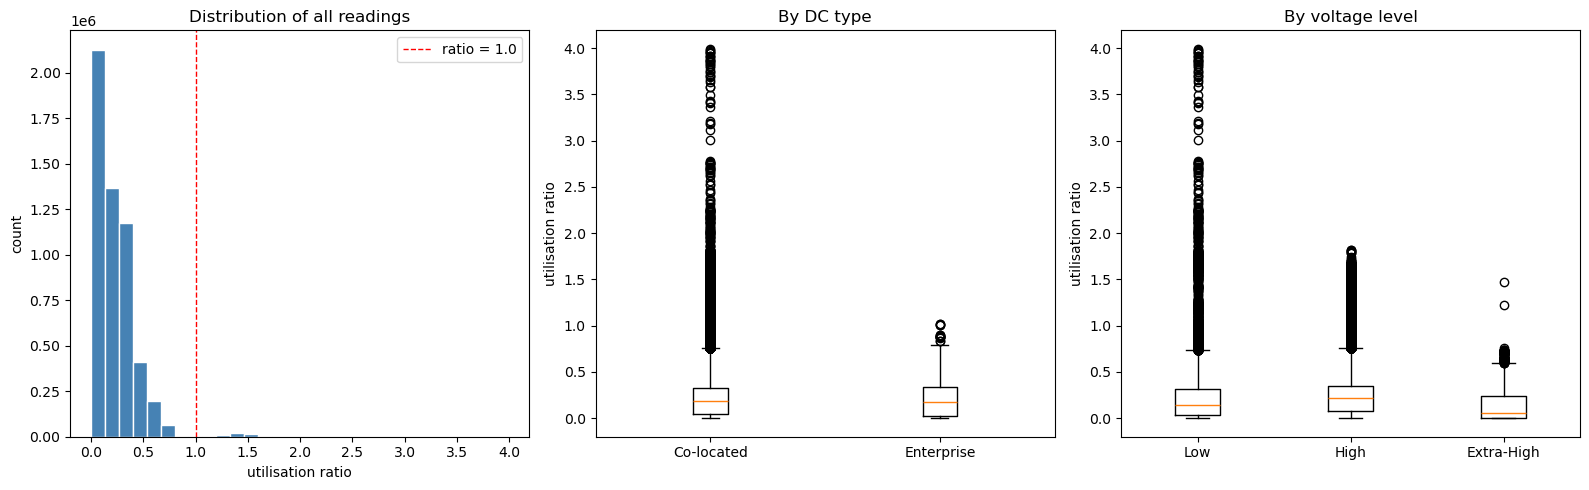

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
axes[0].hist(df[VAL], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(1.0, color="red", ls="--", lw=1, label="ratio = 1.0")
axes[0].set_title("Distribution of all readings")
axes[0].set_xlabel("utilisation ratio")
axes[0].set_ylabel("count")
axes[0].legend()

# boxplot by dc_type
types = sorted(df[TYPE].unique())
axes[1].boxplot([df.loc[df[TYPE] == t, VAL] for t in types], tick_labels=types)
axes[1].set_title("By DC type")
axes[1].set_ylabel("utilisation ratio")

# boxplot by voltage
volts = [v for v in VOLT_ORDER if v in df[VOLT].unique()]
axes[2].boxplot([df.loc[df[VOLT] == v, VAL] for v in volts],
                tick_labels=[v.replace(" Voltage Import", "") for v in volts])
axes[2].set_title("By voltage level")
axes[2].set_ylabel("utilisation ratio")

fig.tight_layout()
plt.show()

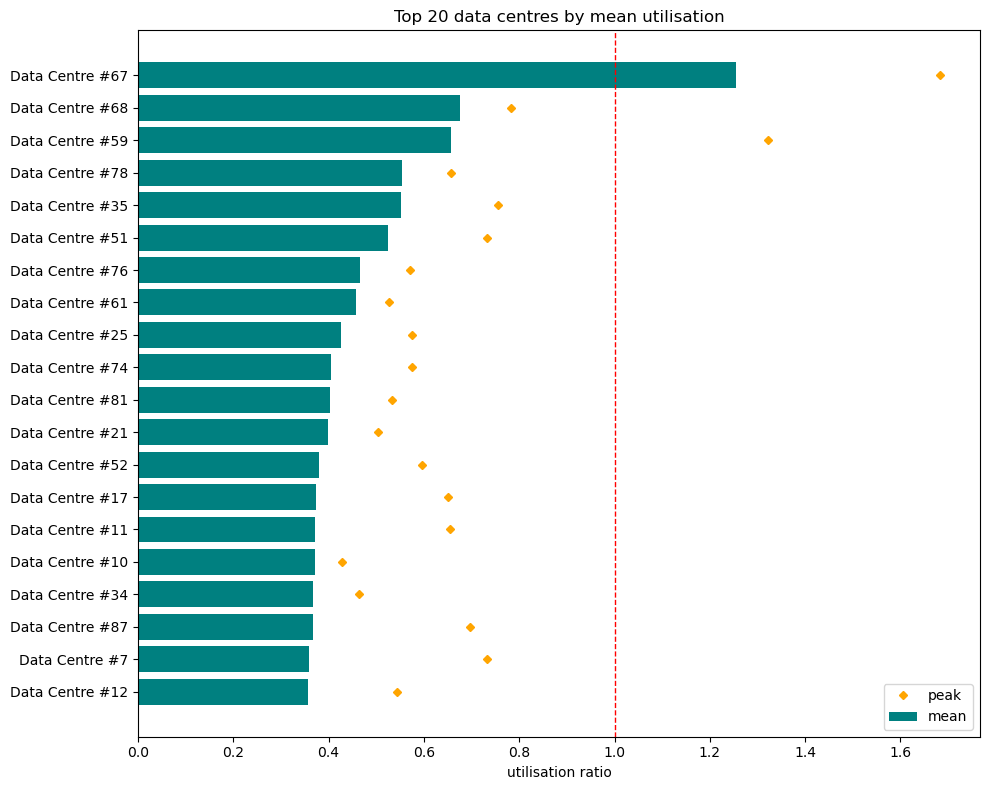

In [14]:
stats = (df.groupby(DC)[VAL]
            .agg(mean="mean", peak="max", n="count")
            .sort_values("mean", ascending=False))

top_n = 20
top = stats.head(top_n)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(top))

ax.barh(y, top["mean"], color="teal", label="mean")
ax.plot(top["peak"], y, "D", color="orange", ms=4, label="peak")
ax.set_yticks(list(y))
ax.set_yticklabels(top.index)
ax.axvline(1.0, color="red", ls="--", lw=1)

ax.set_title(f"Top {top_n} data centres by mean utilisation")
ax.set_xlabel("utilisation ratio")
ax.legend()

fig.tight_layout()
plt.show()

---
---
##### Working on a copy of the heatpump model
---
---

utc_timestamp
0 days 00:30:00    57784
1 days 00:30:00        3
3 days 00:30:00        1
2 days 00:30:00        1
Name: count, dtype: int64


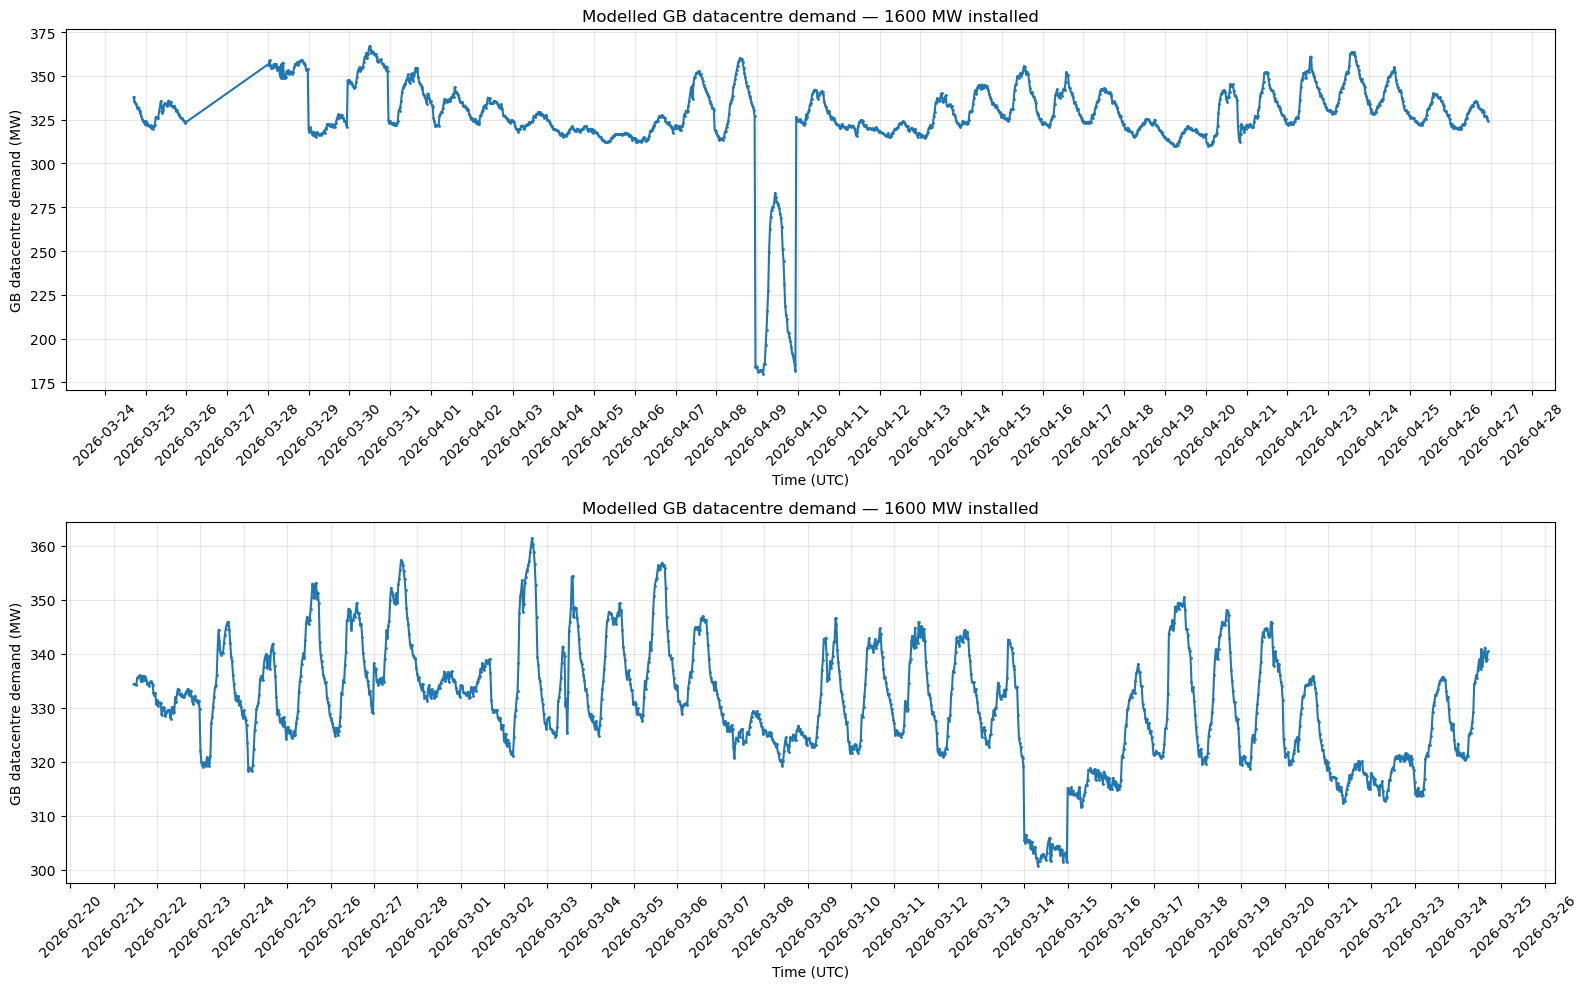

In [ ]:
import matplotlib.dates as mdates

df = pd.read_csv("../tests/ukpn-data-centre-demand-profiles.csv")

# renaming columns for ease of use
UTIL = "hh_utilisation_ratio"
DC_NAME = "anonymised_data_centre_name"
DC_TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TIME = "utc_timestamp"
# ordering voltage -> low to extra high
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]
df[TIME] = pd.to_datetime(df[TIME], utc=True)

total_utilisation_per_dt = df.groupby(TIME)[UTIL].mean().sort_index()
print(total_utilisation_per_dt.index.to_series().diff().value_counts())
# https://www.gov.uk/government/publications/estimate-of-data-centre-capacity-great-britain-2024/estimate-of-data-centre-capacity-great-britain-2024
TOTAL_DC_CAPACITY = 1600 #in MW; 1.6 GW is the current GB capacity

num_modelled_dc = 3
num_dc = df[DC_NAME].nunique()

dc_demand_mw = TOTAL_DC_CAPACITY * total_utilisation_per_dt
dc_demand_mw_per_centre = dc_demand_mw / num_modelled_dc

n =1500
dc_demand_mw_top_1500 = dc_demand_mw.iloc[-n:-1]        # points 0–1499
dc_demand_mw_top_3000 = dc_demand_mw.iloc[-2*n:-n]      # points 1500–2999


fig, ax = plt.subplots(2,1, figsize=(16, 10))
ax[0].plot(dc_demand_mw_top_1500.index, dc_demand_mw_top_1500.values, 
        marker="o", 
        markersize=1)
ax[0].set_xlabel("Time (UTC)")
ax[0].set_ylabel("GB datacentre demand (MW)")
ax[0].set_title(f"Modelled GB datacentre demand — {TOTAL_DC_CAPACITY} MW installed")
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis="x", labelrotation=45)

ax[0].xaxis.set_major_locator(mdates.DayLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))



ax[1].plot(dc_demand_mw_top_3000.index, dc_demand_mw_top_3000.values, 
        marker="o", 
        markersize=1)
ax[1].set_xlabel("Time (UTC)")
ax[1].set_ylabel("GB datacentre demand (MW)")
ax[1].set_title(f"Modelled GB datacentre demand — {TOTAL_DC_CAPACITY} MW installed")
ax[1].grid(True, alpha=0.3)
ax[1].tick_params(axis="x", labelrotation=45)

ax[1].xaxis.set_major_locator(mdates.DayLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.tight_layout()
plt.show()


In [18]:
n = pypsa.Network("../resources/network/Martas_Q2_zonal_2020_solved.nc")
print(n.buses[["x", "y", "carrier"]].to_string())

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Martas_Q2_zonal_2020 (Full)' has buses, carriers, generators, links, loads, storage_units, sub_networks


                                                    x             y carrier
name                                                                       
Z10                                     508272.452661  3.610900e+05      AC
Z11                                     424022.376665  2.968537e+05      AC
Z12                                     567375.298902  2.645857e+05      AC
Z13                                     334888.007379  2.135753e+05      AC
Z14                                     527920.552208  1.835088e+05      AC
Z15                                     597049.193309  1.607791e+05      AC
Z16                                     489487.333776  1.274007e+05      AC
Z17                                     287169.770199  9.649068e+04      AC
Z1_1                                    442009.410351  1.166134e+06      AC
Z1_2                                    114059.413136  9.052043e+05      AC
Z1_3                                    256554.246745  9.157052e+05      AC
Z1_4        

In [ ]:
print("=" *80)
print('If ETYS or REDUCED selected')
print('=' *80)

# scenario A - prioritise wind farms!
# https://www.offshorewindscotland.org.uk/the-offshore-wind-market-in-scotland/
scotland_sites = ["Z1_3", "Z1_4", "Z2"]      # three distinct northern zones

# scenario B — dispersed (north / middle / south)
dispersed_sites = ["Z2", "Z8", "Z14"]

# scenario C — all near London
london_sites = ["Z12", "Z14", "Z16"]

If ETYS or REDUCED selected


---
                                    MARTA'S IMPLEMENTATION                                              
---

In [ ]:
import requests, os, pandas as pd

os.environ["API_KEY"] = "3330fdf9f91aadb09332a4131567fee6f29e327c88a6227401edf5a6"
headers = {"Authorization": f"Apikey {os.environ['API_KEY']}"}
url = ("https://ukpowernetworks.opendatasoft.com/api/explore/v2.1/"
       "catalog/datasets/ukpn-data-centre-demand-profiles/exports/json?lang=en")
r = requests.get(url, headers=headers)
print(r.status_code)
df = pd.DataFrame(r.json())

,Rank,Urban Area,Population Estimate (2025),1 Year Change (over 2024),Land Area (Km2),Density (P/Km2),Projections (2030),Projections (2050),Easting,Northing
0,1,London,"10,416,420",0.82%,"1,646","6,328","10,766,831","11,868,905",530029,180380
1,2,Birmingham,"2,631,757",0.54%,671,"3,922","2,689,574","2,810,468",407540,287592
2,3,Manchester,"2,535,427",0.38%,741,"3,422","2,567,727","2,638,194",383997,398258
3,4,Liverpool,"1,227,470",0.53%,369,"3,326","1,241,135","1,254,523",334179,390634
4,5,Leeds,"1,065,607",0.45%,323,"3,299","1,086,815","1,109,261",429796,433927


Import libraries required

In [31]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import plotly
import seaborn as sb
import matplotlib.pyplot as plt


### Get dataframes needed for the project

#### Data centre demand profiles

In [ ]:
df_dc_demand_profile = pd.read_csv("../tests/ukpn-data-centre-demand-profiles.csv")
df_dc_demand_profile.head()

In [ ]:
# assigning df column names to something shorter for ease
UTIL = "hh_utilisation_ratio"
DC_NAME = "anonymised_data_centre_name"
DC_TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TIME = "utc_timestamp"
# ordering voltage -> low to extra-high
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]
# convert tot date/time
df_dc_demand_profile[TIME] = pd.to_datetime(df_dc_demand_profile[TIME], utc=True)

#### Population data

In [ ]:
# https://www.worldometers.info/population/largest-cities-in-uk/
df_population = pd.read_csv("../tests/uk_largest_cities.csv")

df_population = df_population.drop(columns=['Global Rank'])
df_population.head()

### Create sub-functions to do easy tasks within main functions

In [ ]:
def _nearest_bus(base_network: pypsa.Network, easting, northing):
    '''
    This function finds the nearest bus for the specified location (easting / northing).

    Args:
        - base network: the pypsa baseline network to add data centres to
        - easting and northing of the preferred location
    
    Returns:
        - bus that has to closest to the specified location
    '''

    # get AC buses only
    ac_bus = base_network.buses[base_network.buses.carrier == "AC"]

    # find the distance between selected point and the AC buses
    distance = np.sqrt((ac_bus.x-easting)**2 + (ac_bus.y-northing)**2)
    # select the one with minimum distance
    nearest_bus = distance.idxmin()

    return nearest_bus

def _get_timestep_hours(index: pd.DatetimeIndex, default: float = 1) -> float:
    '''
    This function takes the snapshot of selected time and converts that into hours.

    Args:
        - index: 
        - default: default state in case the number of hours 
    Returns:
        - 
    '''
    if index is None or len(index) < 2:
        return default
    delta_hours = (index[1] - index[0]).total_seconds() / 3600.0
    return delta_hours if delta_hours > 0 else default

def _convert_DC_demand_profile_to_GWh(total_dc_capacity_mw: float, dc_df):
    '''
    This function is for the DC dataframe specifically. It takes the utilisation from the demand profiles 
    '''
    total_utilisation_per_dt = dc_df.groupby(TIME)[UTIL].mean().sort_index()

    dc_demand_mw = total_dc_capacity_mw * total_utilisation_per_dt

    timestep_hours = _get_timestep_hours(dc_demand_mw.index)
    total_dc_demand_mwh = (dc_demand_mw * timestep_hours).sum()
    total_dc_demand_gwh = total_dc_demand_mwh/1000

    return total_dc_demand_gwh

def _get_total_dc_demand_FES(total_gwh: float, fraction = 0.02):
    '''
    This function takes the total load demand - wether it's from historic data or Future Energy Scenario (FES),
    and calculates the DC demand as a fraction of the total demand.

    Args:
        - total_gwh: GB's total load demand in GWh
        - fraction: assumed % of the total demand that data centres account for (0.9–2%, predicted). Default value: 2% = 0.02
    Returns:
        - total_dc_gwh: the total load of data centres, in GWh
    '''
    total_dc_gwh = total_gwh * fraction

    return total_dc_gwh

def _get_total_dc_demand_PLANNED(year: int, dc_prediction_2030_gw: 6.0):
    '''
    This function predicts a compound increase in DC capacity, based on the prediction made for the 2025 -> 2030 increase (1.6 GW -> 6.0 GW).
    This load will be added on top of the overall FES-predicted load / demand.
    Args:
        - year: a year for which you want to predict the capacity for
        - dc_prediciton_20230_gw: helps to calculate rate; assumed to be the current 6.0 GW by default, but can be set to a more pessimistic (4.0 GW) or optimistic (8.0 GW) 
            scenario to affect the rate and predict pessimistic/optmistic future scenarios overall.
    Returns:
        - the total capacity of the data centres
    '''
    # 6.0 (GW planned for 2030) = 1.6 (GW as of 2025) * (1+rate)**5  -> rate = (6.0/1.6)**1/5 - 1
    rate = (dc_prediction_2030_gw/1.6)**(1/5) - 1 
    total_dc_gw = 1.6 * (1+rate)**(2025-year)

    return total_dc_gw

### Create functions that will create the main workflow

In [ ]:


def allocate_north_scotland(total_dc_gwh: float, base_network: pypsa.Network, dc_number: int, logger) -> pd.Series:
    '''
    Make this function such that it takes the number of data centres users wants to create (or just assume unit for a dc, say 300MW),
    their total maximum MW, then find the distinct buses as close to the wind farm point as possible.
    
    Assumptions:
    To not overload the buses, pick one bus per data centre.
    Each data centre is of equal capacity, equating to the total data centre capacity added on to the network / number of data centres.

    Args:
        - total_dc_gwh: the total data centre load
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - dc_number: 
    Returns:
        - dc_allocation: the allocated DC per bus
    '''

    dc_gwh_per_bus = total_dc_gwh / dc_number

    return dc_allocation


def allocate_population_density_weighted(total_dc_gwh: float, base_network: pypsa.Network, dc_number: int, logger) -> pd.Series:
    '''
    This scenario takes into account the highest population density points across the UK 
    and places the data centre capacities proportionally at those locations.

    Args:
        - total_dc_gwh: total load 
    '''

    gwh_per_bus = total_dc_gwh / dc_number

    mid = _nearest_bus(base_network, 430000, 400000) 
    north = _nearest_bus(base_network, 290000, 870000)
    london = _nearest_bus(base_network, 530000, 180000) 
    
    
    
    return dc_allocation

In [21]:
"""
Data Centre Demand Disaggregation and Flexibility

This script disaggregates data centre electricity demand from the total demand
and optionally adds flexibility modelling.

================================================================================
SPACE HEATING FLEXIBILITY MECHANISMS
================================================================================

Both TANK and COSY modes are mechanisms for providing SPACE HEATING flexibility.
They represent different physical storage mechanisms for pre-heating:

TANK Mode (Hot Water Tank Storage):
    - Uses hot water cylinder/tank as thermal energy storage
    - Heat pump pre-heats water stored in tank during low-cost periods
    - Tank releases heat to space heating system when needed
    - Physical component: Hot water cylinder (e.g., 200-500L tank)
    - Typical storage capacity: 10-50 kWh thermal
    - Heat loss: ~1-3% per hour depending on insulation
    - PyPSA components created:
        * Bus: thermal bus for heat flow
        * Store: hot water tank (energy storage in kWh)
        * Link: heat pump (converts electricity to heat at COP efficiency)
        * Load: space heating demand at thermal bus

COSY Mode (Building Thermal Inertia):
    - Uses building thermal mass (walls, floors, furniture) as storage
    - Heat pump pre-heats building fabric during low-cost periods  
    - Building slowly releases stored heat, maintaining comfort
    - Physical component: Building fabric itself (concrete, brick, etc.)
    - Typical storage capacity: 2-10 kWh thermal per 100m² floor area
    - Heat loss: Depends on building insulation (EPC rating)
    - PyPSA components created:
        * Bus: thermal inertia bus for heat flow
        * Store: building thermal mass (energy storage in kWh)
        * Link: heat pump (converts electricity to heat at COP efficiency)
        * Load: space heating demand at thermal bus

Key Equations (same for both modes):
    thermal_demand_mw = electric_demand_mw * COP
    
    Where COP (Coefficient of Performance) is temperature-dependent:
    - Higher COP in milder weather (COP ~4-5 at 10°C ambient)
    - Lower COP in cold weather (COP ~2-3 at 0°C ambient)

Configuration (config/defaults.yaml):
    heat_pumps:
      enabled: true
      flexibility:
        enabled: true
        tank_share: 0.5    # 50% of HP demand uses TANK mechanism
        cosy_share: 0.5    # 50% of HP demand uses COSY mechanism
        # Note: tank_share + cosy_share should equal 1.0

Without flexibility enabled, data centres are modeled as simple Load components
with fixed electricity demand profiles (no shifting capability).
================================================================================
"""

import pandas as pd
import pypsa
import logging
import numpy as np
import xarray as xr
from pathlib import Path
import sys
from typing import Optional, Dict, Any

# Add parent directory to path for imports
sys.path.insert(0, str(Path(__file__).parent.parent))
from scripts.utilities.logging_config import setup_logging
from scripts.utilities.network_io import load_network
from scripts.demand.load import load_spatial_mapping_data, aggregate_demand_to_network_topology

# ──────────────────────────────────────────────────────────────────────────────
# Spatial Allocation Functions
# ──────────────────────────────────────────────────────────────────────────────

def allocate_north(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:

    '''
    Allocate data centres where the most reliable renewable energy is in the UK - wind.
    '''
    logger.info("Allocating all data centres in Northern Scotland")
    load_demand = 
    return dc_allocation


def allocate_proportional(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:
    """
    Allocate data centre demand proportionally to existing base demand.

    This assumes heat pump adoption correlates with overall electricity consumption.
    """
    logger.info("Allocating proportionally to base demand")

    # Get base demand per load (column names are load indices, not bus names)
    if len(base_network.loads_t.p_set) > 0:
        load_demand = base_network.loads_t.p_set.sum(axis=0)  # Sum over time
    else:
        logger.warning("No time-varying loads found, using static p_set")
        load_demand = base_network.loads.p_set

    # Map load demand to buses (aggregate by bus)
    load_to_bus = base_network.loads["bus"]
    valid_loads = [l for l in load_demand.index if l in load_to_bus.index]
    if not valid_loads:
        logger.error("No valid loads found for proportional allocation")
        raise ValueError("No valid loads for allocation")

    load_demand = load_demand.loc[valid_loads]
    bus_mapping = load_to_bus.loc[valid_loads]
    bus_demand = load_demand.groupby(bus_mapping).sum()

    # Calculate fractions
    total_base = bus_demand.sum()
    if total_base == 0:
        logger.error("Total base demand is zero - cannot allocate proportionally")
        raise ValueError("Zero base demand")

    bus_fractions = bus_demand / total_base
    dc_allocation = bus_fractions * total_gwh

    logger.info(f"Allocated {dc_allocation.sum():.1f} GWh across {len(dc_allocation)} buses")
    logger.info(f"Min: {dc_allocation.min():.3f} GWh, Max: {dc_allocation.max():.3f} GWh")

    return dc_allocation


def allocate_uniform(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:
    """
    Allocate data centre demand uniformly across all buses.
    
    This assumes uniform heat pump adoption regardless of location.
    """
    logger.info("Allocating uniformly across all buses")
    
    n_buses = len(base_network.buses)
    dc_per_bus = total_gwh / n_buses
    dc_allocation = pd.Series(dc_per_bus, index=base_network.buses.index)
    
    logger.info(f"Allocated {dc_allocation.sum():.1f} GWh uniformly ({dc_per_bus:.3f} GWh per bus)")
    
    return dc_allocation


def allocate_urban_weighted(total_gwh: float, base_network: pypsa.Network, logger,
                            urban_weight: float = 1.5) -> pd.Series:
    """
    Allocate heat pump demand weighted towards urban areas (high demand buses).

    Uses a power function to weight allocation towards higher-demand areas.
    """
    logger.info("Allocating with urban weighting")

    # Get base demand per load
    if len(base_network.loads_t.p_set) > 0:
        load_demand = base_network.loads_t.p_set.sum(axis=0)
    else:
        load_demand = base_network.loads.p_set

    # Map load demand to buses (aggregate by bus)
    load_to_bus = base_network.loads["bus"]
    valid_loads = [l for l in load_demand.index if l in load_to_bus.index]
    if not valid_loads:
        logger.warning("No valid loads for urban weighting, falling back to proportional")
        return allocate_proportional(total_gwh, base_network, logger)

    load_demand = load_demand.loc[valid_loads]
    bus_mapping = load_to_bus.loc[valid_loads]
    bus_demand = load_demand.groupby(bus_mapping).sum()

    # Apply power weighting (exponent > 1 favors high-demand areas)
    weighted_demand = bus_demand ** urban_weight

    total_weighted = weighted_demand.sum()
    if total_weighted == 0:
        logger.warning("Weighted demand is zero, falling back to proportional")
        return allocate_proportional(total_gwh, base_network, logger)

    bus_fractions = weighted_demand / total_weighted
    hp_allocation = bus_fractions * total_gwh

    logger.info(f"Allocated {hp_allocation.sum():.1f} GWh with urban weighting (exponent={urban_weight})")

    return hp_allocation


# Allocation method registry
ALLOCATION_METHODS = {
    '': allocate_north,
    'uniform': allocate_uniform,
    'urban_weighted': allocate_urban_weighted,
}


def _get_timestep_hours(index: pd.DatetimeIndex, default: float = 1.0) -> float:
    if index is None or len(index) < 2:
        return default
    delta_hours = (index[1] - index[0]).total_seconds() / 3600.0
    return delta_hours if delta_hours > 0 else default


def _get_cop_series(cop_profile: pd.DataFrame,
                    bus: str,
                    snapshots: pd.DatetimeIndex,
                    logger: Optional[logging.Logger] = None) -> pd.Series:
    if cop_profile is None or cop_profile.empty:
        raise ValueError("COP profile is required for heat pump flexibility")

    if bus in cop_profile.columns:
        cop_series = cop_profile[bus]
    elif cop_profile.shape[1] == 1:
        cop_series = cop_profile.iloc[:, 0]
    else:
        raise ValueError(f"No COP series available for bus '{bus}'")

    if snapshots is not None and not cop_series.index.equals(snapshots):
        cop_series = cop_series.reindex(snapshots)
        cop_series = cop_series.interpolate(method="time")

    if cop_series.isna().any():
        raise ValueError(f"COP series has missing values for bus '{bus}'")

    return cop_series


def _bus_coords_kwargs(network: pypsa.Network, source_bus: str) -> Dict[str, float]:
    if source_bus in network.buses.index and {'x', 'y'}.issubset(network.buses.columns):
        return {
            'x': float(network.buses.at[source_bus, 'x']),
            'y': float(network.buses.at[source_bus, 'y']),
        }
    return {}


def _get_fes_scenario_column(df: pd.DataFrame) -> Optional[str]:
    for col in ['FES Pathway', 'FES Scenario', '\ufeffFES Scenario', 'ï»¿FES Scenario']:
        if col in df.columns:
            return col
    return None


def _calculate_fes_fraction(fes_path: str,
                            fes_scenario: str,
                            modelled_year: int,
                            component_blocks: list,
                            logger: logging.Logger) -> Optional[float]:
    if not fes_path or not Path(fes_path).exists():
        return None

    try:
        fes = pd.read_csv(fes_path, low_memory=False)
    except Exception as exc:
        logger.warning(f"Failed to read FES data: {exc}")
        return None

    scenario_col = _get_fes_scenario_column(fes)
    if scenario_col is None or 'Building Block ID Number' not in fes.columns:
        return None

    year_col = str(modelled_year)
    if year_col not in fes.columns:
        return None

    total = fes[
        (fes['Building Block ID Number'] == 'Dem_BB003') &
        (fes[scenario_col] == fes_scenario)
    ]
    comp = fes[
        (fes['Building Block ID Number'].isin(component_blocks)) &
        (fes[scenario_col] == fes_scenario)
    ]

    total_val = pd.to_numeric(total[year_col], errors='coerce').sum()
    comp_val = pd.to_numeric(comp[year_col], errors='coerce').sum()

    if total_val <= 0:
        return None
    return comp_val / total_val


def _load_fes_component_gsp_demand(
    fes_path: str,
    fes_scenario: str,
    modelled_year: int,
    component_blocks: list,
    logger: logging.Logger
) -> Optional[pd.Series]:
    if isinstance(fes_path, list):
        fes_path = fes_path[0] if fes_path else None

    if not fes_path or not Path(fes_path).exists():
        return None

    try:
        fes = pd.read_csv(fes_path, low_memory=False)
    except Exception as exc:
        logger.warning(f"Failed to read FES data: {exc}")
        return None

    scenario_col = _get_fes_scenario_column(fes)
    if scenario_col is None or 'Building Block ID Number' not in fes.columns:
        return None

    year_col = str(modelled_year)
    if year_col not in fes.columns or 'GSP' not in fes.columns:
        return None

    filtered = fes[
        (fes['Building Block ID Number'].isin(component_blocks)) &
        (fes[scenario_col] == fes_scenario)
    ].copy()

    if filtered.empty:
        return None

    filtered = filtered[filtered['GSP'].notna()]
    filtered['GSP'] = filtered['GSP'].astype(str).str.strip()
    filtered['_value'] = pd.to_numeric(filtered[year_col], errors='coerce')

    gsp_demand = filtered.groupby('GSP')['_value'].sum().dropna()
    gsp_demand = gsp_demand[gsp_demand > 0]

    if gsp_demand.empty:
        return None

    logger.info(f"Loaded FES GSP demand for {len(gsp_demand)} GSPs (total {gsp_demand.sum():.1f} GWh)")
    return gsp_demand


def _allocate_using_fes_gsp(
    total_gwh: float,
    base_network: pypsa.Network,
    component_profile: pd.DataFrame,
    fes_path: str,
    fes_scenario: str,
    modelled_year: int,
    network_model: str,
    fes_year: Optional[int],
    component_blocks: list,
    logger: logging.Logger
) -> Optional[pd.Series]:
    if not fes_scenario:
        return None

    gsp_demand = _load_fes_component_gsp_demand(
        fes_path, fes_scenario, modelled_year, component_blocks, logger
    )
    if gsp_demand is None:
        return None

    total_fes = gsp_demand.sum()
    if total_fes <= 0:
        return None

    scaled_gsp = gsp_demand * (total_gwh / total_fes)
    weights = scaled_gsp / scaled_gsp.sum()

    profile_series = component_profile.iloc[:, 0]
    gsp_timeseries = pd.DataFrame(
        {gsp: profile_series * weight for gsp, weight in weights.items()},
        index=component_profile.index
    )

    fes_demand = scaled_gsp.to_frame(name='demand_gwh')
    if isinstance(network_model, list):
        network_model = network_model[0] if network_model else "ETYS"
    if not network_model:
        network_model = "ETYS"
    if isinstance(fes_year, list):
        fes_year = fes_year[0] if fes_year else None
    mapping_year = int(fes_year) if fes_year else 2024
    spatial_mapping = load_spatial_mapping_data(
        network_model, list(fes_demand.index), mapping_year, logger
    )

    aggregated_demand, _ = aggregate_demand_to_network_topology(
        fes_demand,
        gsp_timeseries,
        network_model,
        base_network,
        spatial_mapping,
        logger,
        is_historical=False
    )

    allocation = aggregated_demand.iloc[:, 0]
    allocation = allocation.reindex(base_network.buses.index, fill_value=0.0)
    logger.info(
        f"Allocated {allocation.sum():.1f} GWh across {len(allocation)} buses using FES GSP distribution"
    )
    return allocation

# ──────────────────────────────────────────────────────────────────────────────
# Heat Pump Flexibility Functions
# ──────────────────────────────────────────────────────────────────────────────

def add_hp_as_load(n: pypsa.Network,
                   buses: list,
                   hp_demand_mw: pd.DataFrame,
                   carrier: str = "heat pump",
                   logger: Optional[logging.Logger] = None) -> pypsa.Network:
    """
    Add heat pumps as simple Load components (no flexibility).

    Args:
        n: PyPSA network
        buses: List of bus names
        hp_demand_mw: Heat pump demand time series (MW) with bus columns
        carrier: Carrier name for the loads
        logger: Logger instance

    Returns:
        Network with heat pump loads added
    """
    if logger:
        logger.info("Adding heat pumps as Load components (no flexibility)...")

    for bus in buses:
        if bus in hp_demand_mw.columns:
            load_name = f"{bus} heat pump"
            n.add("Load",
                  load_name,
                  bus=bus,
                  carrier=carrier,
                  p_set=hp_demand_mw[bus])

    if logger:
        logger.info(f"Added {len(buses)} heat pump loads")

    return n


def add_hp_tank_flexibility(n: pypsa.Network,
                            buses: list,
                            hp_demand_mw: pd.DataFrame,
                            cop_profile: pd.DataFrame,
                            config: Dict[str, Any],
                            logger: Optional[logging.Logger] = None,
                            name_suffix: Optional[str] = None) -> pypsa.Network:
    """
    Add heat pump flexibility using hot water tank storage (TANK mode).

    Creates PyPSA components:
    - Bus: thermal bus for hot water
    - Store: hot water tank (thermal energy storage)
    - Link: heat pump (electricity -> thermal with COP efficiency)
    - Load: hot water demand (fixed profile)

    Args:
        n: PyPSA network
        buses: List of electric bus names
        hp_demand_mw: Heat pump demand time series (MW)
        cop_profile: COP time series for heat pumps
        config: Flexibility configuration dict with tank parameters
        logger: Logger instance

    Returns:
        Network with tank flexibility components added
    """
    if logger:
        logger.info("Adding heat pump TANK flexibility...")

    timestep_hours = _get_timestep_hours(hp_demand_mw.index)
    tank_config = config.get('tank', {})
    volume_liters = tank_config.get('volume_liters', 200)
    temp_range = tank_config.get('temp_range', [50, 65])
    standing_loss = tank_config.get('standing_loss_per_hour', 0.01)
    heater_power_kw = tank_config.get('heater_power_kw', 3.0)

    # Calculate tank energy capacity
    # E = m * c * dT, where c = 4.186 kJ/(kg·K), 1 kWh = 3600 kJ
    temp_diff = temp_range[1] - temp_range[0]  # °C
    # 1 liter water = 1 kg, specific heat = 4.186 kJ/(kg·K)
    tank_capacity_kwh = volume_liters * 4.186 * temp_diff / 3600

    if logger:
        logger.info(f"Tank parameters: {volume_liters}L, {temp_range[0]}-{temp_range[1]}°C")
        logger.info(f"Tank capacity: {tank_capacity_kwh:.2f} kWh thermal")
        logger.info(f"Standing loss: {standing_loss*100:.1f}%/hour")

    suffix = f" {name_suffix}" if name_suffix else ""

    buses = [bus for bus in buses if bus in hp_demand_mw.columns]
    if buses:
        demand_totals = hp_demand_mw[buses].sum()
        buses = demand_totals[demand_totals > 0].index.tolist()

    if not buses:
        if logger:
            logger.info("No nonzero heat pump demand for TANK flexibility")
        return n

    thermal_bus_names = []
    thermal_bus_x = []
    thermal_bus_y = []
    store_names = []
    store_buses = []
    store_e_nom = []

    link_names = []
    link_bus0 = []
    link_bus1 = []
    link_p_nom = []
    link_eff = {}

    load_names = []
    load_buses = []
    load_p_set = {}

    for bus in buses:
        thermal_bus = f"{bus} heat"
        tank_name = f"{bus} hot water tank{suffix}"
        hp_link_name = f"{bus} heat pump{suffix}"
        hw_load_name = f"{bus} hot water demand{suffix}"

        if thermal_bus not in n.buses.index:
            thermal_bus_names.append(thermal_bus)
            coords = _bus_coords_kwargs(n, bus)
            if coords:
                thermal_bus_x.append(coords["x"])
                thermal_bus_y.append(coords["y"])

        cop_series = _get_cop_series(cop_profile, bus, n.snapshots, logger)
        electric_demand = hp_demand_mw[bus]
        if not electric_demand.index.equals(n.snapshots):
            electric_demand = electric_demand.reindex(n.snapshots)
            electric_demand = electric_demand.interpolate(method="time")
        if electric_demand.isna().any():
            raise ValueError(f"Heat pump demand has missing values for bus '{bus}'")

        thermal_demand_mw = electric_demand * cop_series
        peak_thermal_mw = thermal_demand_mw.max()
        peak_electric_mw = electric_demand.max()

        # Estimate number of dwellings from peak thermal demand
        peak_thermal_kw_per_dwelling = config.get('peak_thermal_kw_per_dwelling', 10.0)
        n_dwellings = max(1, int(peak_thermal_mw * 1000 / peak_thermal_kw_per_dwelling))
        total_tank_mwh = n_dwellings * tank_capacity_kwh / 1000

        store_names.append(tank_name)
        store_buses.append(thermal_bus)
        store_e_nom.append(total_tank_mwh)

        link_names.append(hp_link_name)
        link_bus0.append(bus)
        link_bus1.append(thermal_bus)
        # Size link to meet peak demand with margin for pre-heating flexibility
        link_sizing_margin = config.get('link_sizing_margin', 1.5)
        link_p_nom.append(peak_electric_mw * link_sizing_margin)
        link_eff[hp_link_name] = cop_series

        load_names.append(hw_load_name)
        load_buses.append(thermal_bus)
        load_p_set[hw_load_name] = thermal_demand_mw

    if thermal_bus_names:
        bus_kwargs = {"carrier": "heat"}
        if len(thermal_bus_x) == len(thermal_bus_names):
            bus_kwargs["x"] = thermal_bus_x
            bus_kwargs["y"] = thermal_bus_y
        n.add("Bus", thermal_bus_names, **bus_kwargs)

    if store_names:
        n.add(
            "Store",
            store_names,
            bus=store_buses,
            carrier="hot water",
            e_nom=store_e_nom,
            e_nom_extendable=False,
            e_cyclic=True,
            standing_loss=standing_loss,
        )

    if link_names:
        eff_df = pd.DataFrame(link_eff, index=n.snapshots)[link_names]
        n.add(
            "Link",
            link_names,
            bus0=link_bus0,
            bus1=link_bus1,
            carrier="heat pump",
            efficiency=eff_df,
            p_nom=link_p_nom,
            p_nom_extendable=False,
        )

    if load_names:
        load_df = pd.DataFrame(load_p_set, index=n.snapshots)[load_names]
        n.add(
            "Load",
            load_names,
            bus=load_buses,
            carrier="hot water demand",
            p_set=load_df,
        )

    if logger:
        logger.info(f"Added TANK flexibility for {len(buses)} buses")
        logger.info(f"Components per bus: 1 thermal bus, 1 store, 1 link, 1 load")

    return n


def add_hp_cosy_flexibility(n: pypsa.Network,
                            buses: list,
                            hp_demand_mw: pd.DataFrame,
                            cop_profile: pd.DataFrame,
                            config: Dict[str, Any],
                            logger: Optional[logging.Logger] = None,
                            name_suffix: Optional[str] = None) -> pypsa.Network:
    """
    Add heat pump flexibility using building thermal inertia (COSY mode).

    COSY (Comfort Optimised Smart Yield) mode pre-heats buildings during
    low-price periods and allows temperature to drift during high-price periods.

    Creates PyPSA components:
    - Bus: thermal inertia bus
    - Store: building thermal mass (state = temperature deviation from setpoint)
    - Link (charge): pre-heating capability
    - Link (discharge): reduced heating (use stored thermal energy)
    - Load: base heating demand

    Args:
        n: PyPSA network
        buses: List of electric bus names
        hp_demand_mw: Heat pump demand time series (MW)
        cop_profile: COP time series for heat pumps
        config: Flexibility configuration dict with COSY parameters
        logger: Logger instance

    Returns:
        Network with COSY flexibility components added
    """
    if logger:
        logger.info("Adding heat pump COSY flexibility (thermal inertia)...")

    cosy_config = config.get('cosy', {})
    morning_window = cosy_config.get('morning_window', ['07:00', '09:00'])
    evening_window = cosy_config.get('evening_window', ['17:00', '19:00'])
    max_temp_deviation = cosy_config.get('max_temp_deviation_celsius', 2.0)
    thermal_mass_hours = cosy_config.get('thermal_mass_hours', 0.3)

    if logger:
        logger.info(f"COSY windows: morning {morning_window}, evening {evening_window}")
        logger.info(f"Max temperature deviation: ±{max_temp_deviation}°C")
        logger.info(f"Thermal mass capacity: {thermal_mass_hours} hours")

    # Create availability profile for pre-heating windows
    # Pre-heating is available in the hours BEFORE peak demand (morning and evening)
    snapshots = n.snapshots
    preheat_avail = pd.Series(0.0, index=snapshots)

    for idx in snapshots:
        hour = idx.hour
        # Morning pre-heat window (before morning peak)
        morning_start = int(morning_window[0].split(':')[0])
        morning_end = int(morning_window[1].split(':')[0])
        # Evening pre-heat window (before evening peak)
        evening_start = int(evening_window[0].split(':')[0])
        evening_end = int(evening_window[1].split(':')[0])

        if morning_start <= hour < morning_end or evening_start <= hour < evening_end:
            preheat_avail[idx] = 1.0

    suffix = f" {name_suffix}" if name_suffix else ""

    buses = [bus for bus in buses if bus in hp_demand_mw.columns]
    if buses:
        demand_totals = hp_demand_mw[buses].sum()
        buses = demand_totals[demand_totals > 0].index.tolist()

    if not buses:
        if logger:
            logger.info("No nonzero heat pump demand for COSY flexibility")
        return n

    thermal_bus_names = []
    thermal_bus_x = []
    thermal_bus_y = []
    store_names = []
    store_buses = []
    store_e_nom = []

    hp_link_names = []
    hp_link_bus0 = []
    hp_link_bus1 = []
    hp_link_p_nom = []

    demand_link_names = []
    demand_link_bus0 = []
    demand_link_bus1 = []
    demand_link_p_nom = []

    load_names = []
    load_buses = []

    hp_eff = {}
    hp_pmax = {}
    load_p_set = {}

    for bus in buses:
        thermal_bus = f"{bus} thermal inertia"
        store_name = f"{bus} building thermal mass"
        hp_link_name = f"{bus} heat pump{suffix}"
        heat_load_name = f"{bus} space heating"

        if thermal_bus not in n.buses.index:
            thermal_bus_names.append(thermal_bus)
            if bus in n.buses.index and "x" in n.buses.columns:
                thermal_bus_x.append(n.buses.at[bus, "x"])
                thermal_bus_y.append(n.buses.at[bus, "y"])

        cop_series = _get_cop_series(cop_profile, bus, n.snapshots, logger)
        electric_demand = hp_demand_mw[bus]
        if not electric_demand.index.equals(n.snapshots):
            electric_demand = electric_demand.reindex(n.snapshots)
            electric_demand = electric_demand.interpolate(method="time")
        if electric_demand.isna().any():
            raise ValueError(f"Heat pump demand has missing values for bus '{bus}'")

        thermal_demand_mw = electric_demand * cop_series
        peak_thermal_mw = thermal_demand_mw.max()
        electric_peak_mw = electric_demand.max()

        thermal_capacity_mwh = peak_thermal_mw * thermal_mass_hours

        store_names.append(store_name)
        store_buses.append(thermal_bus)
        store_e_nom.append(thermal_capacity_mwh)

        hp_link_names.append(hp_link_name)
        hp_link_bus0.append(bus)
        hp_link_bus1.append(thermal_bus)
        link_sizing_margin = config.get('link_sizing_margin', 1.5)
        hp_link_p_nom.append(electric_peak_mw * link_sizing_margin)
        hp_eff[hp_link_name] = cop_series
        hp_pmax[hp_link_name] = 1.0 + preheat_avail * 0.5

        demand_link_names.append(f"{bus} thermal demand")
        demand_link_bus0.append(thermal_bus)
        demand_link_bus1.append(f"{bus} heat sink" if f"{bus} heat sink" in n.buses.index else bus)
        demand_link_p_nom.append(peak_thermal_mw)

        load_names.append(heat_load_name)
        load_buses.append(thermal_bus)
        load_p_set[heat_load_name] = thermal_demand_mw

    if thermal_bus_names:
        bus_kwargs = {"carrier": "thermal inertia"}
        if len(thermal_bus_x) == len(thermal_bus_names):
            bus_kwargs["x"] = thermal_bus_x
            bus_kwargs["y"] = thermal_bus_y
        n.add("Bus", thermal_bus_names, **bus_kwargs)

    if store_names:
        # Note: e_min_pu=0.0 means building thermal mass cannot go below baseline temperature
        # This represents realistic building thermal inertia - you can pre-heat but not pre-cool
        n.add(
            "Store",
            store_names,
            bus=store_buses,
            carrier="thermal inertia",
            e_nom=store_e_nom,
            e_nom_extendable=False,
            e_cyclic=True,
            e_min_pu=0.0,  # Cannot go negative (can't have "borrowed" heat from future)
            e_max_pu=1.0,
            standing_loss=cosy_config.get('standing_loss_per_hour', 0.05),
        )

    if hp_link_names:
        eff_df = pd.DataFrame(hp_eff, index=n.snapshots)[hp_link_names]
        pmax_df = pd.DataFrame(hp_pmax, index=n.snapshots)[hp_link_names]
        n.add(
            "Link",
            hp_link_names,
            bus0=hp_link_bus0,
            bus1=hp_link_bus1,
            carrier="heat pump",
            efficiency=eff_df,
            p_nom=hp_link_p_nom,
            p_nom_extendable=False,
            p_max_pu=pmax_df,
        )

    if demand_link_names:
        n.add(
            "Link",
            demand_link_names,
            bus0=demand_link_bus0,
            bus1=demand_link_bus1,
            carrier="thermal demand",
            efficiency=1.0,
            p_nom=demand_link_p_nom,
            p_nom_extendable=False,
        )

    if load_names:
        load_df = pd.DataFrame(load_p_set, index=n.snapshots)[load_names]
        n.add(
            "Load",
            load_names,
            bus=load_buses,
            carrier="space heating",
            p_set=load_df,
        )

    if logger:
        logger.info(f"Added COSY flexibility for {len(buses)} buses")
        logger.info(f"Components per bus: 1 thermal bus, 1 store, 2 links, 1 load")

    return n


def add_heat_pump_flexibility(n: pypsa.Network,
                              buses: list,
                              hp_demand_mw: pd.DataFrame,
                              cop_profile: pd.DataFrame,
                              flex_config: Dict[str, Any],
                              logger: Optional[logging.Logger] = None) -> pypsa.Network:
    """
    Add heat pump flexibility to network based on configuration.

    This is the main entry point for heat pump flexibility modeling.

    Args:
        n: PyPSA network
        buses: List of bus names with heat pumps
        hp_demand_mw: Heat pump demand time series (MW)
        cop_profile: COP time series
        flex_config: Flexibility configuration from defaults.yaml
        logger: Logger instance

    Returns:
        Network with appropriate flexibility components
    """
    hp_config = flex_config.get('heat_pumps', {})
    enabled = hp_config.get('enabled', False)
    mode = hp_config.get('mode', 'TANK')
    mix_config = hp_config.get('mix', {})
    tank_share = mix_config.get('tank_share')
    cosy_share = mix_config.get('cosy_share')

    if not enabled:
        if logger:
            logger.info("Heat pump flexibility disabled, adding as simple loads")
        return add_hp_as_load(n, buses, hp_demand_mw, logger=logger)

    if logger:
        logger.info(f"Heat pump flexibility enabled, mode: {mode}")

    use_mix = mode.upper() == 'MIXED' or tank_share is not None or cosy_share is not None
    if use_mix:
        if tank_share is None and cosy_share is None:
            raise ValueError("Heat pump MIXED mode requires tank_share or cosy_share")
        if tank_share is None:
            tank_share = 1.0 - float(cosy_share)
        if cosy_share is None:
            cosy_share = 1.0 - float(tank_share)

        total_share = float(tank_share) + float(cosy_share)
        if total_share <= 0:
            raise ValueError("Heat pump mix shares must sum to a positive value")

        tank_share = float(tank_share) / total_share
        cosy_share = float(cosy_share) / total_share

        if logger:
            logger.info(f"Heat pump mix: tank={tank_share:.1%}, cosy={cosy_share:.1%}")

        if tank_share > 0:
            n = add_hp_tank_flexibility(
                n,
                buses,
                hp_demand_mw * tank_share,
                cop_profile,
                hp_config,
                logger,
                name_suffix="tank" if cosy_share > 0 else None
            )
        if cosy_share > 0:
            n = add_hp_cosy_flexibility(
                n,
                buses,
                hp_demand_mw * cosy_share,
                cop_profile,
                hp_config,
                logger,
                name_suffix="cosy" if tank_share > 0 else None
            )
        return n

    if mode.upper() == 'TANK':
        return add_hp_tank_flexibility(n, buses, hp_demand_mw, cop_profile, hp_config, logger)
    if mode.upper() == 'COSY':
        return add_hp_cosy_flexibility(n, buses, hp_demand_mw, cop_profile, hp_config, logger)

    if logger:
        logger.warning(f"Unknown flexibility mode '{mode}', defaulting to simple loads")
    return add_hp_as_load(n, buses, hp_demand_mw, logger=logger)


# ──────────────────────────────────────────────────────────────────────────────
# Main Processing
# ──────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Setup logging
    logger = setup_logging(
        log_path=snakemake.log[0],
        log_level="INFO"
    )
    
    try:
        logger.info("=" * 80)
        logger.info("HEAT PUMP DEMAND DISAGGREGATION")
        logger.info("=" * 80)
        
        # ──── Load Inputs ────
        logger.info("Loading inputs...")
        base_network = load_network(snakemake.input.base_demand, skip_time_series=False, custom_logger=logger)
        base_profile = pd.read_csv(snakemake.input.base_profile, index_col=0, parse_dates=True)
        
        logger.info(f"Base network: {len(base_network.buses)} buses, {len(base_network.loads)} loads")
        logger.info(f"Base profile shape: {base_profile.shape}")

        timestep_hours = _get_timestep_hours(base_profile.index)
        timesteps_per_day = int(round(24 / timestep_hours)) if timestep_hours > 0 else 24
        
        # ──── Get Configuration ────
        config = snakemake.params.component_config
        fraction = config.get("fraction_of_total", 0.15)
        allocation_method = config.get("allocation_method", "proportional")
        source_file = config.get("source_file")
        use_fes_fraction = config.get("use_fes_fraction", False)
        min_gwh_threshold = float(config.get("min_gwh_threshold", 0.0))
        fes_fraction = None

        if not snakemake.params.is_historical:
            fes_fraction = _calculate_fes_fraction(
                snakemake.input.fes_data,
                snakemake.params.fes_scenario,
                snakemake.params.modelled_year,
                ['Dem_BB004', 'Dem_BB005'],
                logger
            )
            if fes_fraction is not None:
                logger.info(f"FES heat pump fraction: {fes_fraction:.2%}")
                if use_fes_fraction:
                    fraction = fes_fraction
        
        logger.info(f"Configuration:")
        logger.info(f"  Fraction of total demand: {fraction:.1%}")
        logger.info(f"  Allocation method: {allocation_method}")
        logger.info(f"  Source file: {source_file}")
        logger.info(f"  Min GWh threshold: {min_gwh_threshold}")
        
        # ──── Calculate Total HP Demand ────
        logger.info("Calculating heat pump demand...")
        
        # Get total base demand from profile (MW -> GWh)
        total_base_demand_mwh = base_profile.sum().sum() * timestep_hours
        total_base_demand_gwh = total_base_demand_mwh / 1000.0
        total_hp_demand_gwh = total_base_demand_gwh * fraction
        total_hp_demand_mwh = total_hp_demand_gwh * 1000.0
        
        logger.info(f"Total base demand: {total_base_demand_gwh:.1f} GWh/year")
        logger.info(f"Target HP demand: {total_hp_demand_gwh:.1f} GWh/year ({fraction:.1%})")
        
        # ──── Load Atlite-Generated Heat Profiles ────
        logger.info("Loading Atlite-generated heat demand and COP profiles...")

        # Load heat demand profile from Atlite (NetCDF)
        heat_demand_nc = xr.open_dataset(snakemake.input.heat_demand_profile)
        cop_ashp_nc = xr.open_dataset(snakemake.input.cop_ashp_profile)

        logger.info(f"Heat demand profile shape: {heat_demand_nc['heat_demand'].shape}")
        logger.info(f"COP ASHP profile shape: {cop_ashp_nc['cop'].shape}")

        # Aggregate spatially (mean across GB) to get single time series
        # The Atlite profiles are gridded (time, y, x) - we take spatial mean for national profile
        heat_demand_timeseries = heat_demand_nc['heat_demand'].mean(dim=['y', 'x']).to_pandas()
        cop_timeseries = cop_ashp_nc['cop'].mean(dim=['y', 'x']).to_pandas()

        logger.info(f"Heat demand timeseries: {len(heat_demand_timeseries)} timesteps")
        logger.info(f"COP timeseries range: {cop_timeseries.min():.2f} to {cop_timeseries.max():.2f}")

        # Align to base_profile index
        if not heat_demand_timeseries.index.equals(base_profile.index):
            logger.info("Reindexing Atlite profiles to match base profile timestamps...")
            logger.info(f"  Source: {len(heat_demand_timeseries)} timesteps ({heat_demand_timeseries.index[0]} to {heat_demand_timeseries.index[-1]})")
            logger.info(f"  Target: {len(base_profile.index)} timesteps ({base_profile.index[0]} to {base_profile.index[-1]})")

            # Handle year mismatch (e.g., 2020 leap year weather → 2035 non-leap year scenario)
            # Align by day-of-year and hour rather than absolute timestamp
            source_year = heat_demand_timeseries.index[0].year
            target_year = base_profile.index[0].year

            if source_year != target_year:
                logger.info(f"  Year mismatch detected: source={source_year}, target={target_year}")
                logger.info(f"  Aligning by day-of-year and hour...")

                # Create temporary index with year normalized to target year
                # This handles leap year → non-leap year transitions
                source_normalized = heat_demand_timeseries.copy()
                source_normalized.index = pd.to_datetime({
                    'year': target_year,
                    'month': heat_demand_timeseries.index.month,
                    'day': heat_demand_timeseries.index.day,
                    'hour': heat_demand_timeseries.index.hour
                }, errors='coerce')

                cop_normalized = cop_timeseries.copy()
                cop_normalized.index = pd.to_datetime({
                    'year': target_year,
                    'month': cop_timeseries.index.month,
                    'day': cop_timeseries.index.day,
                    'hour': cop_timeseries.index.hour
                }, errors='coerce')

                # Remove any invalid dates (e.g., Feb 29 in non-leap year)
                source_normalized = source_normalized[source_normalized.index.notna()]
                cop_normalized = cop_normalized[cop_normalized.index.notna()]

                # Now reindex to base_profile
                heat_demand_timeseries = source_normalized.reindex(base_profile.index)
                cop_timeseries = cop_normalized.reindex(base_profile.index)
            else:
                # Use time-based resampling instead of reindex to preserve temporal variation
                # Resample to hourly frequency matching the base profile
                heat_demand_timeseries = heat_demand_timeseries.resample('h').mean()
                cop_timeseries = cop_timeseries.resample('h').mean()

                # Now align to base_profile index (should be very close after resampling)
                heat_demand_timeseries = heat_demand_timeseries.reindex(base_profile.index)
                cop_timeseries = cop_timeseries.reindex(base_profile.index)

            # Fill any NaN values (e.g., from minor timestamp mismatches)
            heat_demand_timeseries = heat_demand_timeseries.interpolate(method='time').ffill().bfill()
            cop_timeseries = cop_timeseries.interpolate(method='time').ffill().bfill()

            logger.info(f"  After reindexing: COP range {cop_timeseries.min():.2f} to {cop_timeseries.max():.2f}")

        # The heat_demand from Atlite is normalized (heating degree hours fraction)
        # Use this as the thermal demand shape
        profile_shape = heat_demand_timeseries

        # Store the COP profile from Atlite
        cop_profile = cop_timeseries

        # Close NetCDF files
        heat_demand_nc.close()
        cop_ashp_nc.close()

        logger.info(f"Loaded Atlite profiles - Heat demand shape: {profile_shape.shape}, COP mean: {cop_profile.mean():.2f}")

        shape_energy_mwh = profile_shape.sum() * timestep_hours
        if shape_energy_mwh <= 0:
            raise ValueError("HP profile has zero or negative energy")

        # COP profile is already loaded from Atlite (temperature-dependent)
        logger.info(f"Using Atlite COP profile - range: {cop_profile.min():.2f} to {cop_profile.max():.2f} (mean: {cop_profile.mean():.2f})")

        # ──── Calculate Thermal and Electrical Demand ────
        # The FES/config gives us ELECTRICAL demand (total_hp_demand_gwh)
        # We need:
        #   - thermal_demand = profile_shape (normalized) representing heat needed
        #   - electrical_demand = thermal_demand / COP
        #   - Total electrical energy must match total_hp_demand_gwh

        # Normalize the thermal demand shape
        thermal_shape_normalized = profile_shape / profile_shape.sum()

        # The electrical demand shape is thermal_shape / COP (element-wise)
        # We need to find the scaling factor so that:
        #   sum(thermal_demand / COP * timestep_hours) = total_hp_demand_mwh
        # Let thermal_demand = scale * thermal_shape_normalized
        # Then: scale * sum(thermal_shape_normalized / COP) * timestep_hours = total_hp_demand_mwh
        # Therefore: scale = total_hp_demand_mwh / (sum(thermal_shape_normalized / COP) * timestep_hours)

        electrical_shape = thermal_shape_normalized / cop_profile
        electrical_shape_energy = electrical_shape.sum() * timestep_hours

        # Scale factor to get correct total electrical energy
        scale_factor = total_hp_demand_mwh / electrical_shape_energy

        # Final profiles
        thermal_demand_mw = thermal_shape_normalized * scale_factor  # MW thermal
        electrical_demand_mw = thermal_demand_mw / cop_profile  # MW electrical

        # Verify: electrical demand should sum to total_hp_demand_mwh
        actual_electrical_mwh = electrical_demand_mw.sum() * timestep_hours
        actual_thermal_mwh = thermal_demand_mw.sum() * timestep_hours

        logger.info(f"Thermal demand: {actual_thermal_mwh/1000:.1f} GWh/year")
        logger.info(f"Electrical demand: {actual_electrical_mwh/1000:.1f} GWh/year (target: {total_hp_demand_gwh:.1f} GWh)")
        logger.info(f"Effective annual COP: {actual_thermal_mwh/actual_electrical_mwh:.2f}")

        # The profile we save is the ELECTRICAL demand (what the grid sees)
        hp_profile = pd.DataFrame(
            electrical_demand_mw,
            index=base_profile.index,
            columns=['heat_pump_demand_mw']
        )

        # Also save COP profile for flexibility modeling
        cop_df = pd.DataFrame(
            cop_profile,
            index=base_profile.index,
            columns=['cop']
        )

        hp_profile_total_gwh = hp_profile.sum().sum() * timestep_hours / 1000.0
        logger.info(f"HP electrical profile total: {hp_profile_total_gwh:.1f} GWh (check: {total_hp_demand_gwh:.1f} GWh)")
        if fes_fraction is not None and not use_fes_fraction:
            diff = abs(fes_fraction - fraction)
            logger.info(f"FES fraction vs config: {fes_fraction:.2%} vs {fraction:.2%} (diff {diff:.2%})")
        
        # ──── Spatial Allocation ────
        logger.info(f"Allocating HP demand across buses using '{allocation_method}' method...")

        if allocation_method in {"fes", "fes_gsp"} and not snakemake.params.is_historical:
            hp_allocation = _allocate_using_fes_gsp(
                total_hp_demand_gwh,
                base_network,
                hp_profile,
                snakemake.input.fes_data,
                snakemake.params.fes_scenario,
                snakemake.params.modelled_year,
                snakemake.params.network_model,
                snakemake.params.fes_year,
                ['Dem_BB004', 'Dem_BB005'],
                logger
            )
            if hp_allocation is None:
                logger.warning("FES GSP allocation unavailable - falling back to proportional allocation")
                hp_allocation = allocate_proportional(total_hp_demand_gwh, base_network, logger)
                allocation_method = 'proportional'
        else:
            if allocation_method not in ALLOCATION_METHODS:
                logger.warning(f"Unknown allocation method '{allocation_method}', using 'proportional'")
                allocation_method = 'proportional'

            allocator = ALLOCATION_METHODS[allocation_method]
            if allocation_method == 'urban_weighted':
                hp_urban_weight = config.get('urban_weight', 1.5)
                hp_allocation = allocator(total_hp_demand_gwh, base_network, logger, urban_weight=hp_urban_weight)
            else:
                hp_allocation = allocator(total_hp_demand_gwh, base_network, logger)

        if min_gwh_threshold > 0:
            below = hp_allocation < min_gwh_threshold
            dropped = int(below.sum())
            dropped_total = hp_allocation[below].sum()
            remaining_total = hp_allocation[~below].sum()
            if remaining_total <= 0:
                raise ValueError("Min GWh threshold removed all heat pump allocations")
            scale = total_hp_demand_gwh / remaining_total
            hp_allocation = hp_allocation.copy()
            hp_allocation[below] = 0.0
            hp_allocation[~below] = hp_allocation[~below] * scale
            logger.info(
                f"Dropped {dropped} buses below {min_gwh_threshold} GWh "
                f"(removed {dropped_total:.3f} GWh, rescaled by {scale:.4f})"
            )
        # ──── Validation ────
        logger.info("Validating outputs...")
        
        profile_total = hp_profile.sum().sum() * timestep_hours / 1000.0
        allocation_total = hp_allocation.sum()
        
        tolerance = 0.01  # 0.01 GWh = 10 MWh
        if abs(profile_total - allocation_total) > tolerance:
            logger.warning(
                f"Energy balance mismatch! "
                f"Profile: {profile_total:.3f} GWh, "
                f"Allocation: {allocation_total:.3f} GWh, "
                f"Difference: {abs(profile_total - allocation_total):.3f} GWh"
            )
        else:
            logger.info(f"Energy balance check: PASSED ✓ (difference < {tolerance} GWh)")
        
        # Check that allocation matches network topology
        network_buses = set(base_network.buses.index)
        allocation_buses = set(hp_allocation.index)
        
        if network_buses != allocation_buses:
            missing = network_buses - allocation_buses
            extra = allocation_buses - network_buses
            if missing:
                logger.warning(f"{len(missing)} buses in network but not in allocation")
            if extra:
                logger.warning(f"{len(extra)} buses in allocation but not in network")
        else:
            logger.info("Bus topology check: PASSED ✓")
        
        # ──── Save Outputs ────
        logger.info("Saving outputs...")

        # Save electrical demand profile (timeseries) - this is what the grid sees
        hp_profile.to_csv(snakemake.output.profile)
        logger.info(f"Saved HP electrical profile to {snakemake.output.profile}")

        # Save allocation (spatial distribution)
        hp_allocation_df = pd.DataFrame({
            'bus': hp_allocation.index,
            'heat_pump_demand_gwh': hp_allocation.values
        })
        hp_allocation_df.to_csv(snakemake.output.allocation, index=False)
        logger.info(f"Saved HP allocation to {snakemake.output.allocation}")

        # Save COP profile for flexibility modeling
        cop_df.to_csv(snakemake.output.cop_profile)
        logger.info(f"Saved COP profile to {snakemake.output.cop_profile}")

        # Save thermal demand profile for reference
        thermal_df = pd.DataFrame(
            thermal_demand_mw,
            index=base_profile.index,
            columns=['thermal_demand_mw']
        )
        thermal_df.to_csv(snakemake.output.thermal_profile)
        logger.info(f"Saved thermal profile to {snakemake.output.thermal_profile}")
        
        # ──── Summary ────
        logger.info("=" * 80)
        logger.info("SUMMARY")
        logger.info("=" * 80)
        logger.info(f"Total HP electrical demand: {hp_profile_total_gwh:.1f} GWh/year")
        logger.info(f"Total HP thermal demand: {actual_thermal_mwh/1000:.1f} GWh/year")
        logger.info(f"Effective annual COP: {actual_thermal_mwh/actual_electrical_mwh:.2f}")
        logger.info(f"COP range: {cop_profile.min():.2f} - {cop_profile.max():.2f}")
        logger.info(f"Fraction of base demand: {fraction:.1%}")
        logger.info(f"Number of buses: {len(hp_allocation)}")
        logger.info(f"Allocation method: {allocation_method}")
        logger.info(f"Profile timesteps: {len(hp_profile)}")
        logger.info(f"Min bus demand: {hp_allocation.min():.3f} GWh")
        logger.info(f"Max bus demand: {hp_allocation.max():.3f} GWh")
        logger.info(f"Mean bus demand: {hp_allocation.mean():.3f} GWh")
        logger.info("=" * 80)
        logger.info("HEAT PUMP DISAGGREGATION COMPLETED SUCCESSFULLY ✓")
        logger.info("=" * 80)
        
    except Exception as e:
        logger.error(f"Error in heat pump disaggregation: {e}", exc_info=True)
        raise



SyntaxError: invalid syntax (4259563351.py, line 86)